# Seaborn Basics for Scientific Visualization

**Objective**: This notebook demonstrates the use of Seaborn for high-level statistical data visualization, using the classic Palmer Penguins dataset.

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Load dataset and drop missing values for cleaner analysis
df_penguins = pd.read_csv('../data/penguins.csv')
df_penguins.dropna(inplace=True)

# Quick inspection of the dataset
print("Dataset Info:")
df_penguins.info()
print("\nFirst 5 rows:")
df_penguins.head()

Dataset Info:
<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.8 KB

First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## 1. Categorical Count Plot

`countplot` is the standard way to visualize the frequency of categorical variables. It shows the exact count of each category.

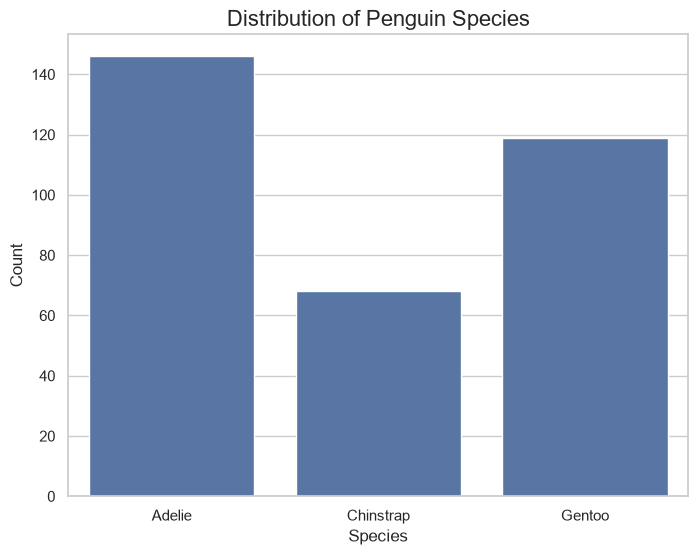

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_penguins, x='species')

plt.title('Distribution of Penguin Species', fontsize=16)
plt.xlabel('Species', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

## 2. Distribution Plot (Histogram with KDE)
`histplot` with `kde=True` effectively visualizes the distribution of a numerical feature, combining a histogram with a Kernel Density Estimate (smooth curve).

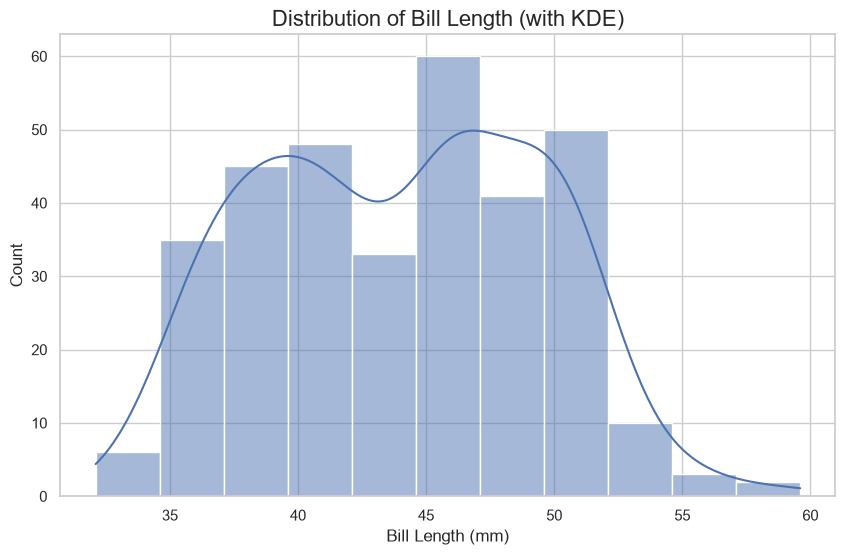

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_penguins, x='bill_length_mm', kde=True)

plt.title('Distribution of Bill Length (with KDE)', fontsize=16)
plt.xlabel('Bill Length (mm)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

## 3. Comparing Categorical and Numerical Data

Here we demonstrate the difference between `countplot` and `histplot` when dealing with categorical data. Both are valid, but serve different purposes.

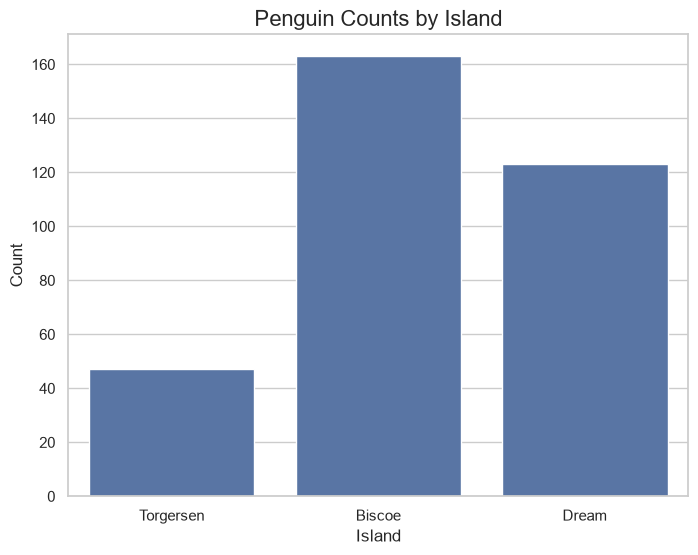

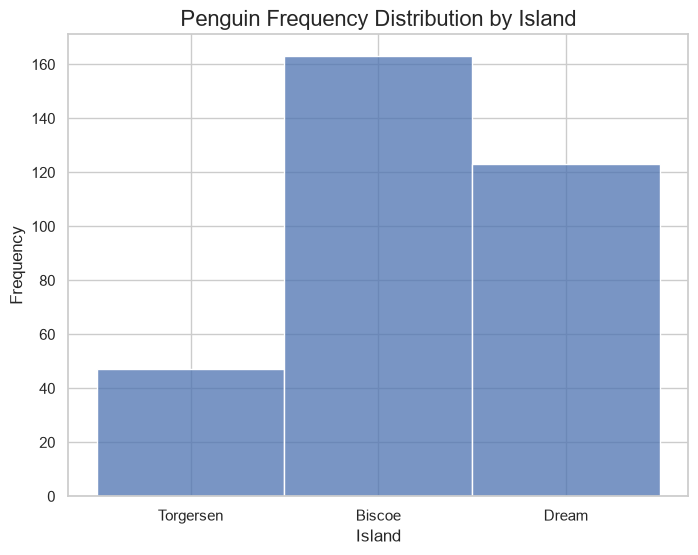

In [20]:
# 1. Using countplot to show exact counts for each island
plt.figure(figsize=(8, 6))
sns.countplot(data=df_penguins, x='island')

plt.title('Penguin Counts by Island', fontsize=16)
plt.xlabel('Island', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# 2. Using histplot to visualize the frequency distribution
plt.figure(figsize=(8, 6))
sns.histplot(data=df_penguins, x='island')

plt.title('Penguin Frequency Distribution by Island', fontsize=16)
plt.xlabel('Island', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

## 4. Scatter Plot with Hue (Multivariate Analysis)

Scatter plots are essential for exploring relationships between two numerical variables. The `hue` parameter allows us to color-code data points by a third categorical variable (e.g., `sex`).

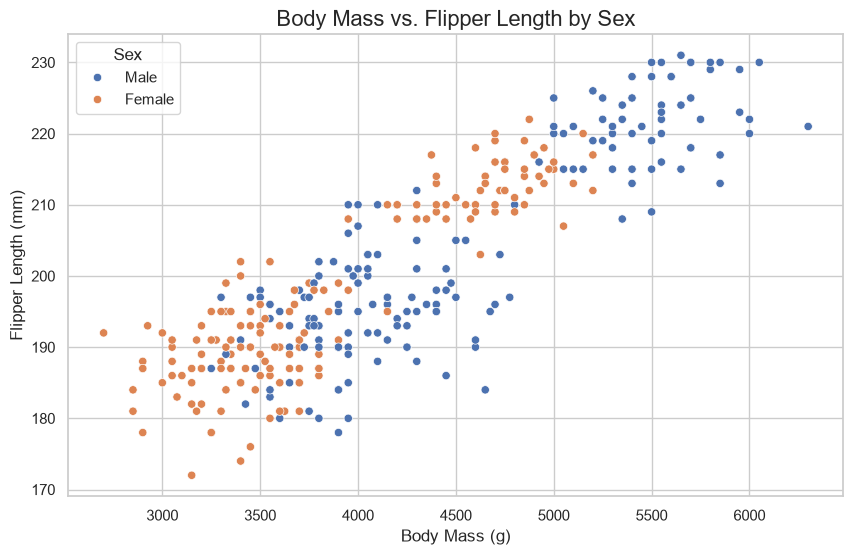

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_penguins, x='body_mass_g', y='flipper_length_mm', hue='sex')

plt.title('Body Mass vs. Flipper Length by Sex', fontsize=16)
plt.xlabel('Body Mass (g)', fontsize=12)
plt.ylabel('Flipper Length (mm)', fontsize=12)
plt.legend(title='Sex')
plt.show()

## 5. Joint Plot (Distribution and Correlation)

`jointplot` is a powerful tool that combines a central scatter plot with marginal histograms (or KDEs) on the axes, providing a comprehensive view of the relationship and the individual distributions.

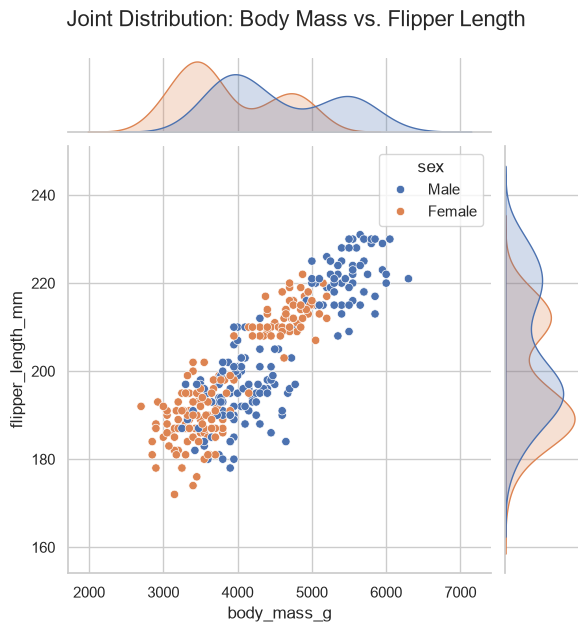

In [22]:
# jointplot returns a JointGrid object, so we manage the title via its figure attribute
g = sns.jointplot(data=df_penguins, x='body_mass_g', y='flipper_length_mm', hue='sex')
g.fig.suptitle('Joint Distribution: Body Mass vs. Flipper Length', y=1.05, fontsize=16)
plt.show()

## 6. Pair Plot (Exploratory Data Analysis)

`pairplot` creates a grid of all pairwise relationships across multiple numerical features. It is an excellent first step for Exploratory Data Analysis (EDA).

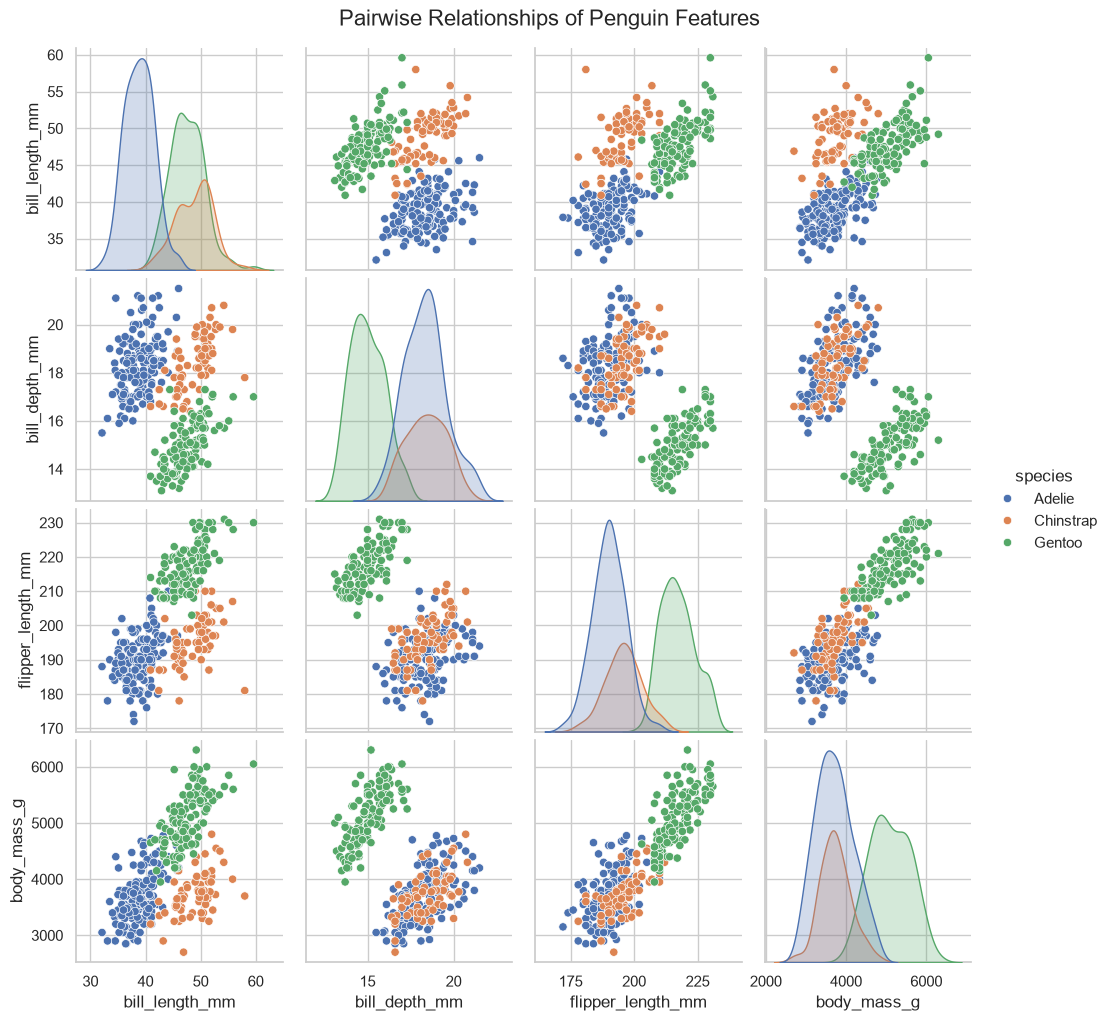

In [23]:
# diag_kind='kde' adds smooth density curves to the diagonal plots
g = sns.pairplot(data=df_penguins, hue='species', diag_kind='kde')
g.fig.suptitle('Pairwise Relationships of Penguin Features', y=1.02, fontsize=16)
plt.show()